In [1]:
import numpy as np
import pandas as pd
import hist
from hist import Hist
import awkward as ak
import json
import uproot
import math
from coffea import util
import pandas as pd
import pickle
from coffea.hist import clopper_pearson_interval, poisson_interval
from copy import copy, deepcopy
import ROOT as r

import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

/cvmfs/sft-nightlies.cern.ch/lcg/views/dev4/Tue/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/coffea/util.py:154: FutureWarning: In coffea version v2023.3.0 (target date: 31 Mar 2023), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


Welcome to JupyROOT 6.28/11


In [2]:
out_dir = "../outfiles/Run3Summer22EE/cutflow/working_example"

era = "Run3Summer22EE"

# Table of contents <a class="anchor" id="toc"></a>

* [Create pseudo data](#data)

# Create pseduodata <a class="anchor" id="data"></a>
[TOC](#toc)

/cvmfs/sft-nightlies.cern.ch/lcg/views/dev4/Wed/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/hist/basehist.py:325: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/cvmfs/sft-nightlies.cern.ch/lcg/views/dev4/Wed/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/hist/basehist.py:325: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


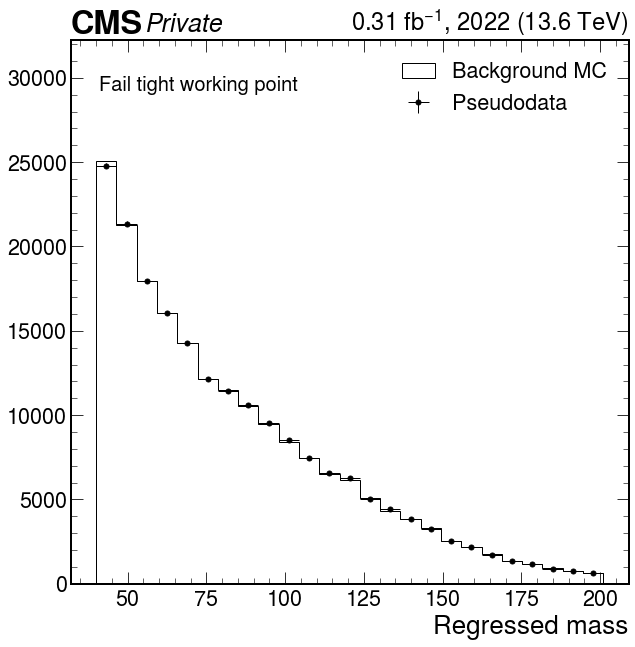

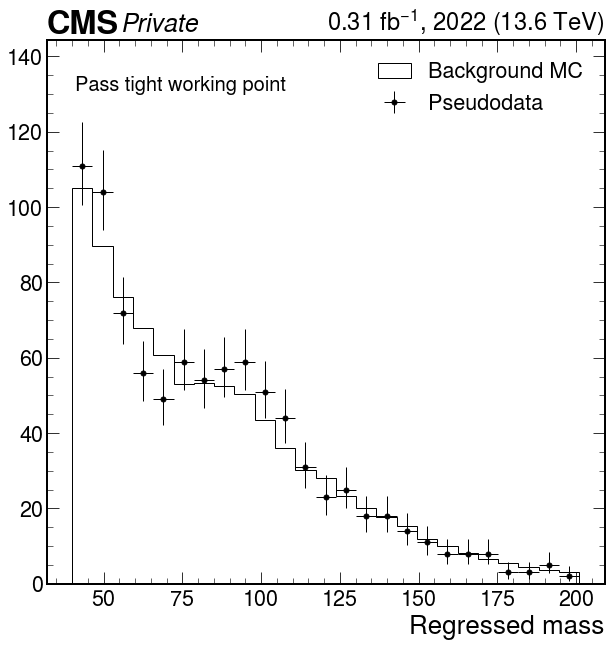

In [21]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
lumi = mc['lumi']
mc = mc["hist"]

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 3
rbin = 2

def get_region(h, region):
    
    h = h[{"pt" : slice(hist.loc(350), len, sum)}]
    
    if "Pass" in region:
        
        h_qcd = h[{'process' : hist.loc('QCD')}][:, 0:wp:sum][hist.rebin(rbin)]
        h_qcd = h_qcd * (h.project("disc")[wp:len:sum].value / h.project("disc")[0:wp:sum].value)
                
        h_rest = h[{
            'process' : [hist.loc('TTbar'), hist.loc('ZJets'), hist.loc('W'), hist.loc('Bkg. H')]
        }][:, wp:len:sum, sum][hist.rebin(rbin)]
        
        h = h_qcd + h_rest
    else:
        h_qcd = h[{'process' : hist.loc('QCD')}][:, 0:wp:sum][hist.rebin(rbin)]
                
        h_rest = h[{
            'process' : [hist.loc('TTbar'), hist.loc('ZJets'), hist.loc('W'), hist.loc('Bkg. H')]
        }][:, 0:wp:sum, sum][hist.rebin(rbin)]
        
        h = h_qcd + h_rest
        
    return h

mchist = mc.project('reg', 'cut', 'disc', 'pt', 'process')[
    :, 5, :, :, [hist.loc('TTbar'), hist.loc('QCD'), hist.loc('ZJets'), hist.loc('W'), hist.loc('Bkg. H')]
][:, :, :, :]

pickle_dict = {}

for region in ['Fail', 'Pass']:
        
    rhist = get_region(mchist, region)
    bin_values = rhist.axes[0].centers
    poisson_means = rhist.values()
    
    pseudodata = Hist(
        hist.axis.Regular(int(50/rbin), 40, 201, name="reg", label=r"Regressed mass"),
        storage=hist.storage.Weight(),
    )
    
    values = np.repeat(bin_values, np.random.poisson(poisson_means)) 
    pseudodata.fill(values)
    
    pickle_dict[region] = pseudodata
    
    fig, ax = plt.subplots(
        1, 1, figsize=(10, 10)
    )
    fig.subplots_adjust(hspace=0.1)
    
    mplhep.histplot(
        rhist,
        ax=ax,
        label="Background MC",
        color="white",
        histtype="fill",
        edgecolor="black",
        linewidth=1,
        flow="none",
    )
    
    mplhep.histplot(
        pseudodata, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Pseudodata",
        flow="none",
    )
    
    plt.text(0.05, 0.9, f"{region} {wps[wp]} working point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumi/1000:.2f}",
            com=13.6,
            )
    
    ax.legend(loc="upper right")
    ax.set_ylim(0, max(pseudodata.values()) * 1.3)
    
picklename = f"{out_dir}/pseudodata.pkl"
outfile = open(picklename, 'wb')
pickle.dump(pickle_dict, outfile, protocol=-1)
outfile.close()

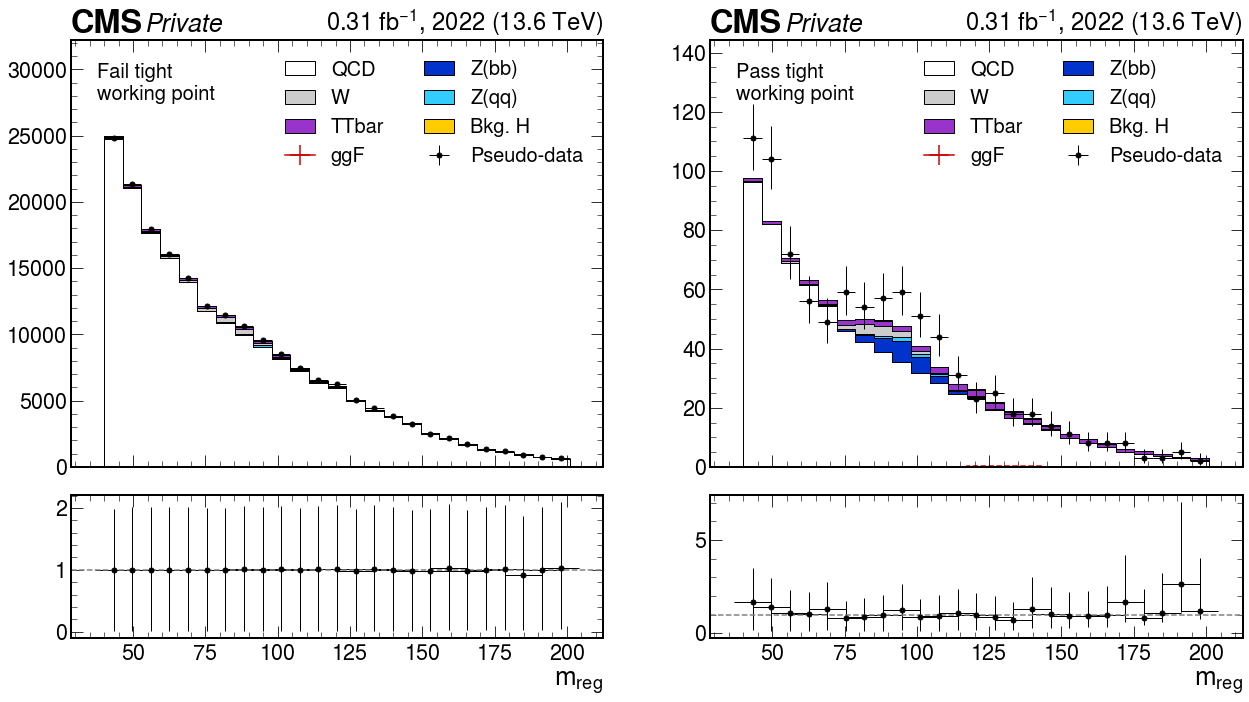

In [22]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
lumi = mc['lumi']
mc = mc["hist"]
data = pickle.load(open(f'{out_dir}/pseudodata.pkl','rb'))

colour = {
    "QCD" : "white",
    "Z(bb)" : "#0033cc",
    "Z(qq)" : "#33ccff",
    "W" : "#cccccc",
    "TTbar" : "#9933cc",
#     "Single t" : "#ff66cc",
#     "VV" : "#ff9900",
    "Bkg. H" : "#ffcc00",
}

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 3
rbin = 2
blind = True

def get_region(h, region, process):
    
    h = h[{"pt" : slice(hist.loc(350), len, sum)}]
    
    if "Pass" in region:        
        if process == "QCD":
            scale = h[:, wp:4:sum].sum().value / h[:, 0:wp:sum].sum().value
            h = h[:, 0:wp:sum][hist.rebin(rbin)] * scale
        elif process == "data" and blind:
            h = h[:, wp:4:sum][hist.rebin(rbin)]
            for i in [12, 13, 14, 15]:
                h[i] = [np.nan, np.nan]
        else:
            h = h[:, wp:4:sum][hist.rebin(rbin)]
        
    else:
        h = h[:, 0:wp:sum][hist.rebin(rbin)]
        
    return h

fig, ((ax1, ax2), (rax1, rax2)) = plt.subplots(
    2, 2, figsize=(21, 11), gridspec_kw={"height_ratios": (3, 1)}, sharex=True
)
fig.subplots_adjust(hspace=0.1)

for region, ax, rax in [("Fail", ax1, rax1), ("Pass", ax2, rax2)]:
    
    ax.set_xlabel(" ")
    rax.set_xlabel(r"$m_{reg}$")
    
    hs = []
    labels = []
    colours = []

    for process in colour.keys():
        
        h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")
        
        if process[0] == "Z":
            if process == "Z(bb)":
                h = h[:, 5, hist.loc("ZJets"), :, 3:4:sum, :]
            else:
                h = h[:, 5, hist.loc("ZJets"), :, 1:3:sum, :]
        else:
            h = h[:, 5, hist.loc(process), :, 0:len:sum, :]
            
        h = get_region(h, region, process)
                    
        hs.append(h)
        labels.append(process)
        colours.append(colour[process])

    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
#         sort="y_r",
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
        flow="none",
    )
    
    h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")[
        :, 5, hist.loc("ggF"), :, 0:len:sum, :
    ]
    
    h = get_region(h, region, "ggF")
    
    mplhep.histplot(
        h, 
        ax=ax, 
        color="#cc0000",
        label=f"ggF",
        linestyle="dashed",
        flow="none",
    )
            
    h = data[region]

    mplhep.histplot(
        h, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Pseudo-data",
        flow="none",
    )
    
    h_mc = mc.project("reg", "cut", "process", "disc", "genflav", "pt")[
        :, 5, 0:len:sum, :, 0:len:sum, :
    ]
    
    h_mc = get_region(h_mc, region, "All mc")
    
    centers = h.axes[0].centers
    sumw_num, sumw2_num = h.values(), h.variances()
    sumw_denom, sumw2_denom = h_mc.values(), h_mc.variances()
    
    rsumw = sumw_num / np.maximum(1, sumw_denom)
    rsumw_unc = poisson_interval(
        rsumw,
        sumw2_num / sumw_denom**2
    )
    
    data_err_opts = {
        'linestyle': 'none',
        'marker': '.',
        'markersize': 10.,
        'color': 'k',
        'elinewidth': 1,
    }
    
    rax.errorbar(
        centers,
        rsumw,
        xerr=centers[1]-centers[0],
        yerr=rsumw_unc,
        **data_err_opts,
    )
    
    rax.axhline(1, color='gray',ls='--')

    plt.text(0.05, 0.85, f"{region} {wps[wp]}\nworking point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumi/1000:.2f}",
            com=13.6,
            )
    
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 3, 4, 6, 1, 2, 5, 7]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=20, ncols=2)
    
    if 'Pass' in region:
        ax.set_ylim(0, max(h.values()) * 1.3)
    else:
        ax.set_ylim(0, max(h.values()) * 1.3)

In [23]:
import shutil
import os

old_name = '../outfiles/Run3Summer22EE/roothist/1pt-hist.root'
new_name = '../outfiles/Run3Summer22EE/roothist/1pt-hist-pseudodata.root'

if os.path.isfile(new_name):
    os.remove(new_name)

shutil.copyfile(old_name, new_name)

data = pickle.load(open(f'{out_dir}/pseudodata.pkl','rb'))

i = 0

with uproot.update(new_name) as fout:
    fout["ggf_pass_pt"+str(i+1)+"_data_nominal"] = data["Pass"]
    fout["ggf_fail_pt"+str(i+1)+"_data_nominal"] = data["Fail"]

with uproot.open(new_name) as fin:
    for name in fin.keys():
        print(name)

ggf_pass_pt1_QCD_nominal;1
ggf_fail_pt1_QCD_nominal;1
ggf_pass_pt1_TTbar_nominal;1
ggf_fail_pt1_TTbar_nominal;1
ggf_pass_pt1_W_nominal;1
ggf_fail_pt1_W_nominal;1
ggf_pass_pt1_ggF_nominal;1
ggf_fail_pt1_ggF_nominal;1
ggf_pass_pt1_VBF_nominal;1
ggf_fail_pt1_VBF_nominal;1
ggf_pass_pt1_ZH_nominal;1
ggf_fail_pt1_ZH_nominal;1
ggf_pass_pt1_WH_nominal;1
ggf_fail_pt1_WH_nominal;1
ggf_pass_pt1_ttH_nominal;1
ggf_fail_pt1_ttH_nominal;1
ggf_pass_pt1_ZJetsqq_nominal;1
ggf_fail_pt1_ZJetsqq_nominal;1
ggf_pass_pt1_ZJetsbb_nominal;1
ggf_fail_pt1_ZJetsbb_nominal;1
ggf_pass_pt1_data_nominal;1
ggf_fail_pt1_data_nominal;1


In [3]:
new_name = '../outfiles/Run3Summer22EE/roothist/1pt-hist-pseudodata.root'

f = uproot.open(new_name)

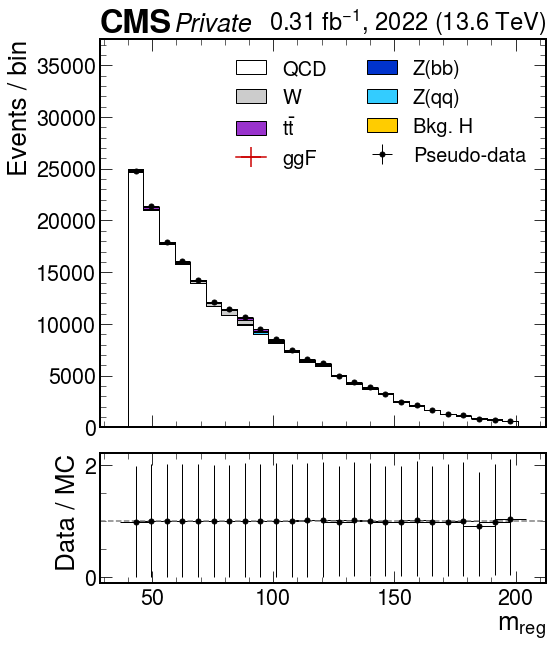

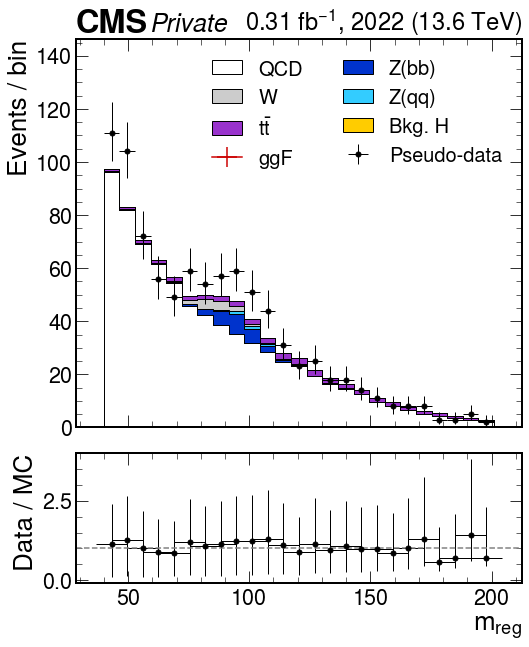

In [5]:
plt.style.use(mplhep.style.CMS)

colour = {
    "QCD" : "white",
    "ZJetsbb" : "#0033cc",
    "ZJetsqq" : "#33ccff",
    "W" : "#cccccc",
    "TTbar" : "#9933cc",
#     "Single t" : "#ff66cc",
#     "VV" : "#ff9900",
}

label = {
    "QCD" : "QCD",
    "ZJetsbb" : "Z(bb)",
    "ZJetsqq" : "Z(qq)",
    "W" : "W",
    "TTbar" : r"$t\bar{t}$",
    "Single t" : "Single t",
    "VV" : "#ff9900",
}

for reg in ['fail', 'pass']:
    
    hs = []
    labels = []
    colours = []

    fig, (ax, rax) = plt.subplots(
        2, 1, figsize=(8, 10), gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events / bin")
    rax.set_ylabel("Data / MC")
    rax.set_xlabel(r"m$_{reg}$")
    ax.set_xlabel(" ")
    
    for process in colour.keys():

        h = f[f'ggf_{reg}_pt1_{process}_nominal'].to_hist()
        
        hs.append(h)
        labels.append(label[process])
        colours.append(colour[process])
        
    higgs_h = None
    
    for process in ['VBF', 'ZH', 'WH', 'ttH']:

        h = f[f'ggf_{reg}_pt1_{process}_nominal'].to_hist()
        
        if not higgs_h:
            higgs_h = h
        else:
            higgs_h += h
        
    hs.append(higgs_h)
    labels.append("Bkg. H")
    colours.append("#ffcc00")
    
    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
        flow="none",
    )
    
    h = f[f'ggf_{reg}_pt1_ggF_nominal'].to_hist()
    
    mplhep.histplot(
        h, 
        ax=ax,
        color="#cc0000",
        label=f"ggF",
        linestyle="dashed",
        flow="none",
    )
    
    h = f[f'ggf_{reg}_pt1_data_nominal'].to_hist()
    
    mplhep.histplot(
        h, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Pseudo-data",
        flow="none",
    )
    
    hs_mc = None
    for h_mc in hs:
        if not hs_mc:
            hs_mc = h_mc
        else:
            hs_mc += h_mc
    
    centers = h.axes[0].centers
    sumw_num, sumw2_num = h.values(), h.variances()
    sumw_denom, sumw2_denom = hs_mc.values(), hs_mc.variances()
    
    rsumw = sumw_num / np.maximum(1, sumw_denom)
    rsumw_unc = poisson_interval(
        rsumw,
        sumw2_num / sumw_denom**2
    )
    
    data_err_opts = {
        'linestyle': 'none',
        'marker': '.',
        'markersize': 10.,
        'color': 'k',
        'elinewidth': 1,
    }
    
    rax.errorbar(
        centers,
        rsumw,
        xerr=centers[1]-centers[0],
        yerr=rsumw_unc,
        **data_err_opts,
    )

    rax.axhline(1, color='gray',ls='--')
    
    mplhep.cms.label(
        ax=ax, 
        data=True, 
        fontsize=25,
        label="Private",
        year=2022,
        lumi=f"{0.31:.2f}",
        com=13.6,
    )
    
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 3, 4, 6, 1, 2, 5, 7]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=20, ncols=2)
    
    ax.set_ylim(0, max(hs[0].values()) * 1.5)